# KNN Anomaly Detection — Hyperparameter Comparison

This notebook follows the same workflow as `knn_5_euclidean.ipynb` but runs the model across **6 hyperparameter combinations** to compare their performance.

**Combinations tested:**

| # | K (neighbors) | Metric | Threshold |
|---|---|---|---|
| 1 | 3 | euclidean | p95 |
| 2 | 4 | euclidean | p95 |
| 3 | 5 | euclidean | p95 |
| 4 | 3 | cosine | p95 |
| 5 | 4 | cosine | p95 |
| 6 | 5 | cosine | p95 |

**What we are varying:**
- **K** — controls how many neighbors influence the anomaly score. Small K is sensitive to local structure; large K averages over a wider neighborhood and smooths out noise.
- **Metric** — `euclidean` measures straight-line distance between spectra (sensitive to magnitude); `cosine` measures the angle between spectra (sensitive to shape, ignores magnitude).

**Threshold is fixed at p95** across all runs so that differences in performance come purely from K and metric, not the threshold.

## 1. Hyperparameter Grid

All combinations are defined here. Add or remove entries to experiment with other values.

In [62]:
# ── Define all hyperparameter combinations to compare ───────────────────────

CONFIGS = [
    {'k': 3,   'metric': 'euclidean', 'threshold_pct': 95},
    {'k': 4,  'metric': 'euclidean', 'threshold_pct': 95},
    {'k': 5, 'metric': 'euclidean', 'threshold_pct': 95},
    {'k': 3,   'metric': 'cosine',    'threshold_pct': 95},
    {'k': 4,  'metric': 'cosine',    'threshold_pct': 95},
    {'k': 5, 'metric': 'cosine',    'threshold_pct': 95},
]

# ─────────────────────────────────────────────────────────────────────────────

print(f'{len(CONFIGS)} configurations to evaluate:')
for i, c in enumerate(CONFIGS, 1):
    print(f'  [{i}] K={c["k"]:<4}  metric={c["metric"]:<10}  threshold=p{c["threshold_pct"]}')

6 configurations to evaluate:
  [1] K=3     metric=euclidean   threshold=p95
  [2] K=4     metric=euclidean   threshold=p95
  [3] K=5     metric=euclidean   threshold=p95
  [4] K=3     metric=cosine      threshold=p95
  [5] K=4     metric=cosine      threshold=p95
  [6] K=5     metric=cosine      threshold=p95


## 2. Imports

Loading all libraries needed for the KNN model, evaluation metrics, and plotting.

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## 3. Load Data

Data is loaded once and reused across all configurations.

- `all_spectra.csv` → **normal** particles (training set)
- `ambient_spectra.csv` → **anomaly** particles (evaluation only)

In [64]:
# Load both datasets
all_spectra     = pd.read_csv('../data/all_spectra.csv',     index_col=0)
ambient_spectra = pd.read_csv('../data/ambient_spectra.csv', index_col=0)

# Separate wavelength features from the polymer label column
label_col   = 'polymer'
wavelengths = [c for c in all_spectra.columns if c != label_col]

# Feature matrices
X_normal  = all_spectra[wavelengths].values      # (1215, 535)
X_anomaly = ambient_spectra[wavelengths].values  # (55, 535)

# Ground truth labels: 0 = normal, 1 = anomaly
true_labels = np.concatenate([
    np.zeros(len(X_normal)),
    np.ones(len(X_anomaly))
])

print(f'Normal samples  : {X_normal.shape}')
print(f'Anomaly samples : {X_anomaly.shape}')

Normal samples  : (1215, 535)
Anomaly samples : (55, 535)


## 4. Run All Configurations

For each configuration, the following steps are performed (identical to `knn_5_euclidean.ipynb`):
1. Train `NearestNeighbors` on the normal samples
2. Compute the mean KNN distance (anomaly score) for every sample
3. Set the decision threshold at the chosen percentile of normal scores
4. Predict labels and compute evaluation metrics

All results are stored in a list for plotting and comparison.

In [65]:
results = []  # stores output for each configuration

for cfg in CONFIGS:
    k           = cfg['k']
    metric      = cfg['metric']
    thresh_pct  = cfg['threshold_pct']
    label       = f"K={k}, {metric}, p{thresh_pct}"

    # Train KNN on normal samples only
    knn = NearestNeighbors(n_neighbors=k, metric=metric)
    knn.fit(X_normal)

    # Compute mean KNN distance as anomaly score
    scores_normal,  _ = knn.kneighbors(X_normal)
    scores_anomaly, _ = knn.kneighbors(X_anomaly)
    scores_normal  = scores_normal.mean(axis=1)
    scores_anomaly = scores_anomaly.mean(axis=1)

    # Set threshold at the chosen percentile of normal scores
    threshold = np.percentile(scores_normal, thresh_pct)

    # Combine scores and predict labels
    all_scores  = np.concatenate([scores_normal, scores_anomaly])
    pred_labels = (all_scores > threshold).astype(int)

    # Compute metrics
    roc_auc = roc_auc_score(true_labels, all_scores)
    cm      = confusion_matrix(true_labels, pred_labels)
    fpr, tpr, _ = roc_curve(true_labels, all_scores)

    # Extract TP, TN, FP, FN from confusion matrix
    tn, fp, fn, tp = cm.ravel()
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    results.append({
        'label':          label,
        'k':              k,
        'metric':         metric,
        'threshold_pct':  thresh_pct,
        'threshold':      threshold,
        'scores_normal':  scores_normal,
        'scores_anomaly': scores_anomaly,
        'all_scores':     all_scores,
        'pred_labels':    pred_labels,
        'roc_auc':        roc_auc,
        'cm':             cm,
        'fpr':            fpr,
        'tpr':            tpr,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'recall':         recall,
        'precision':      precision,
    })

    print(f'[{label}]  AUC={roc_auc:.3f}  TP={tp}  FN={fn}  FP={fp}  TN={tn}  Recall={recall:.2f}')

print('\nDone.')

[K=3, euclidean, p95]  AUC=0.922  TP=25  FN=30  FP=61  TN=1154  Recall=0.45
[K=4, euclidean, p95]  AUC=0.899  TP=20  FN=35  FP=61  TN=1154  Recall=0.36
[K=5, euclidean, p95]  AUC=0.884  TP=16  FN=39  FP=61  TN=1154  Recall=0.29
[K=3, cosine, p95]  AUC=0.878  TP=13  FN=42  FP=61  TN=1154  Recall=0.24
[K=4, cosine, p95]  AUC=0.864  TP=7  FN=48  FP=61  TN=1154  Recall=0.13
[K=5, cosine, p95]  AUC=0.855  TP=5  FN=50  FP=61  TN=1154  Recall=0.09

Done.


## 5. Anomaly Score Distributions

One histogram per configuration. The blue bars are normal samples, orange are ambient (anomaly) samples, and the red dashed line is the decision threshold.

**What to look for:** configurations where the orange and blue distributions are most separated indicate a better-performing model.

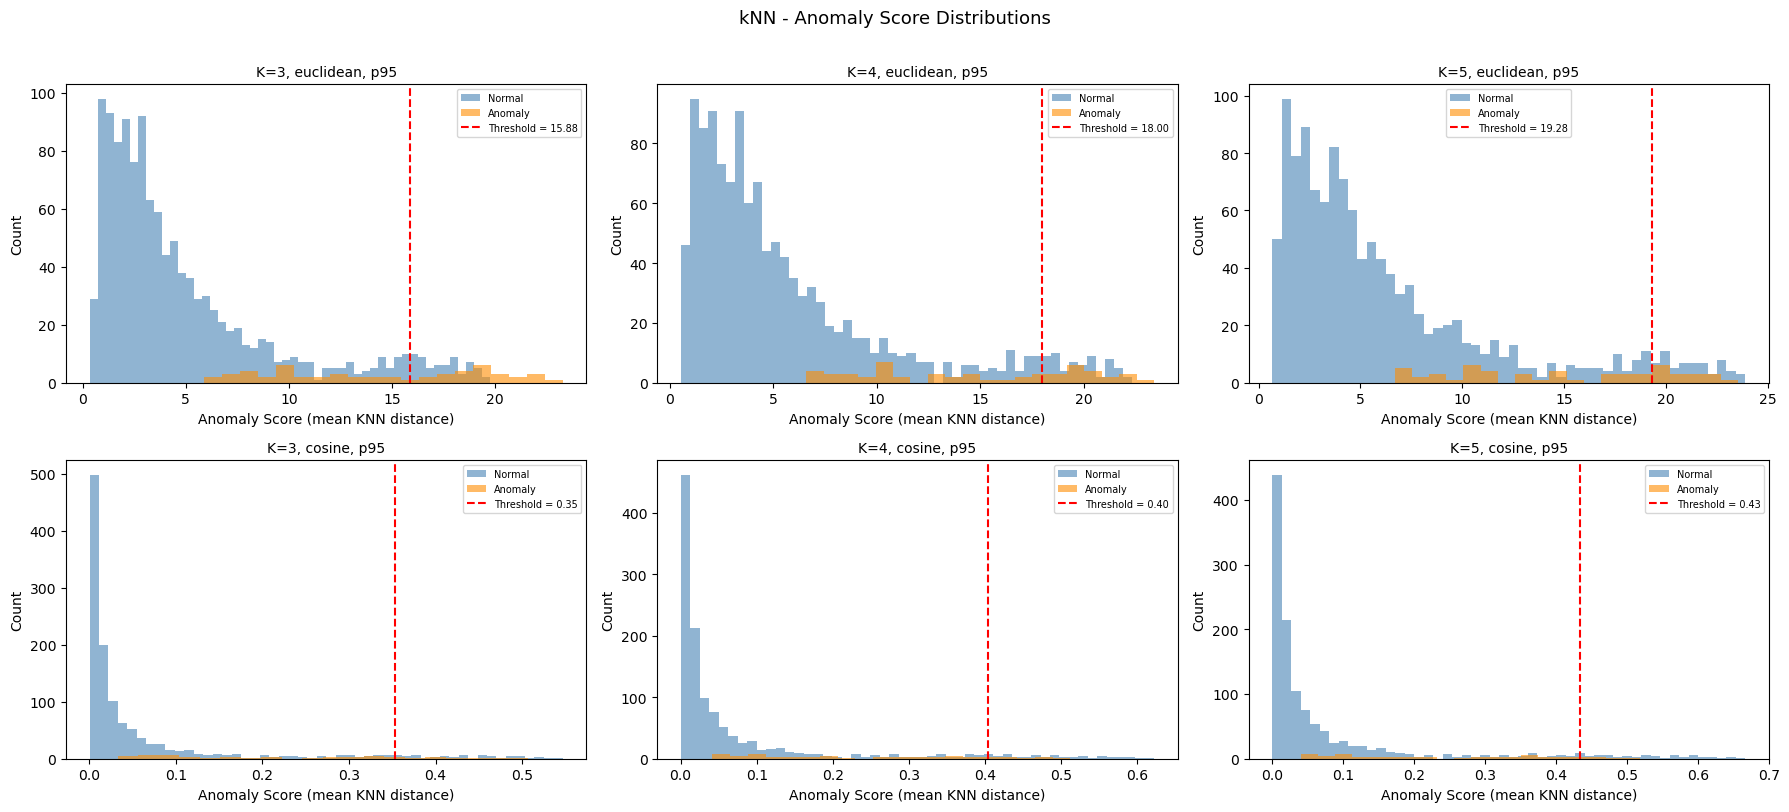

In [66]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, r in enumerate(results):
    ax = axes[i]

    # Plot score distributions
    ax.hist(r['scores_normal'],  bins=50, alpha=0.6, color='steelblue',  label='Normal')
    ax.hist(r['scores_anomaly'], bins=20, alpha=0.6, color='darkorange', label='Anomaly')

    # Draw decision threshold
    ax.axvline(r['threshold'], color='red', linestyle='--', linewidth=1.5,
               label=f'Threshold = {r["threshold"]:.2f}')

    ax.set_title(r['label'], fontsize=10)
    ax.set_xlabel('Anomaly Score (mean KNN distance)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.suptitle('kNN - Anomaly Score Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/knn_anomaly_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

**Euclidean row (top):**

- **K=3, euclidean, p95 (threshold=15.88)** — Normal scores peak sharply at 0–5 and tail off to ~25. Anomaly scores spread broadly across 0–25. The lowest threshold of the euclidean configs means more ambient samples fall above it — this is the best performing euclidean plot visually.
- **K=4, euclidean, p95 (threshold=18.00)** — Very similar shape to K=3 but the threshold shifts right to 18.00, cutting off slightly fewer anomalies. The overlap pattern is largely the same.
- **K=5, euclidean, p95 (threshold=19.28)** — Threshold pushes further right to 19.28. Fewest anomalies above threshold among the euclidean configs. The pattern confirms that increasing K raises the threshold and catches fewer anomalies.

**Overall for euclidean:** Smaller K produces a lower threshold, giving the model a better chance of catching ambient samples. As K increases from 3→4→5, the threshold shifts right and fewer anomalies are detected. The distributions still overlap heavily, but the lower threshold at K=3 provides a meaningful advantage.

---

**Cosine row (bottom):**

- **K=3, cosine, p95 (threshold=0.35)** — Normal scores collapse tightly near 0 with a very tall narrow peak. Anomaly scores spread broadly to ~0.55. The threshold at 0.35 is the lowest of the cosine configs, but most anomaly scores still cluster near 0 and fall below it.
- **K=4, cosine, p95 (threshold=0.40)** — Nearly identical shape to K=3. Threshold shifts slightly right to 0.40. Anomaly scores spread to ~0.65.
- **K=5, cosine, p95 (threshold=0.43)** — Threshold at 0.43. Anomaly scores spread to ~0.67. The cosine distributions show the same pattern as euclidean — increasing K raises the threshold and hurts detection.

**Overall for cosine:** Cosine compresses normal scores very tightly near 0 across all K values. Despite the cleaner normal distribution, the anomaly scores also cluster near 0, which means most ambient samples still look "normal" to the model regardless of K.

---

**Key Takeaway:** Smaller K is consistently better for both metrics. Euclidean with K=3 shows the best visual separation, with the threshold sitting lower and catching more anomalies. Cosine distributions are tighter but do not produce enough separation between normal and anomaly scores to outperform euclidean.

## 6. Confusion Matrices

One confusion matrix per configuration, labeled with TN, FP, FN, TP.

**What to look for:** high TP (anomalies correctly caught) and low FN (anomalies missed). FN is the most costly error in anomaly detection.

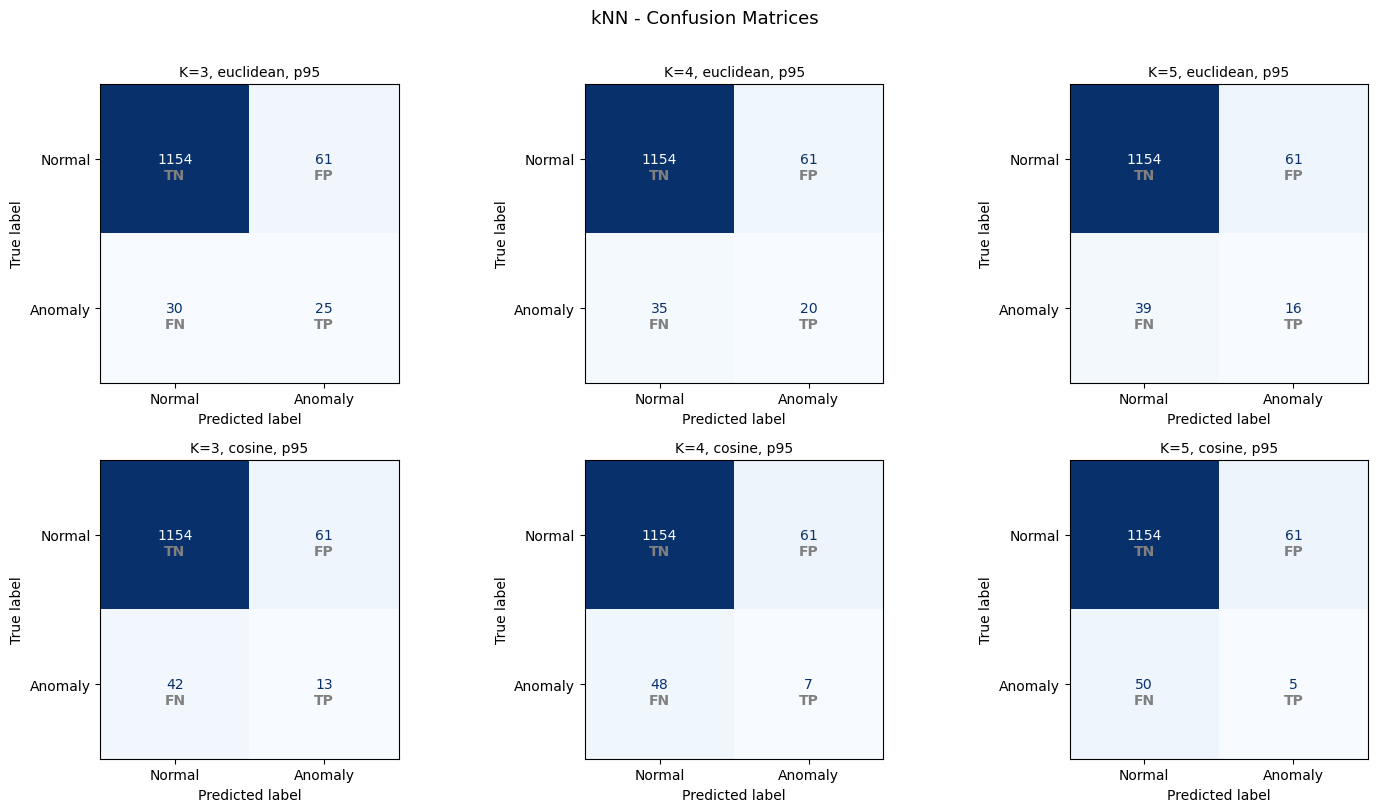

In [67]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

cell_labels = [['TN', 'FP'], ['FN', 'TP']]

for i, r in enumerate(results):
    ax = axes[i]

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=r['cm'], display_labels=['Normal', 'Anomaly'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    # Overlay TP/TN/FP/FN labels
    for row in range(2):
        for col in range(2):
            ax.text(col, row, f'\n\n{cell_labels[row][col]}', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='gray')

    ax.set_title(r['label'], fontsize=10)

plt.suptitle('kNN - Confusion Matrices', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/knn_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

**Euclidean row (top)** — clear improvement as K decreases:
- **K=3:** TP=25, FN=30 — best of all 6 configurations. Caught 45% of anomalies
- **K=4:** TP=20, FN=35 — second best overall
- **K=5:** TP=16, FN=39 — weakest of the euclidean configs

**Cosine row (bottom)** — all configs perform worse than euclidean:
- **K=3:** TP=13, FN=42 — best cosine configuration but still well behind K=3 euclidean
- **K=4:** TP=7, FN=48 — significant drop from K=3 cosine
- **K=5:** TP=5, FN=50 — worst of all 6 configurations

**What stays constant:** All configurations share **FP=61 and TN=1154** — the threshold behaviour for normal samples is identical across all runs since the threshold percentile is fixed at p95.

**Key Takeaway:** Euclidean at K=3 is the clear winner with the highest TP and lowest FN. The trend across both metrics is consistent — smaller K catches more anomalies. Cosine consistently underperforms euclidean at every K value for this dataset.

## 7. ROC Curves

All 6 ROC curves plotted together on one chart for easy comparison. A curve closer to the top-left corner means better performance. The gray dashed diagonal is the random baseline (AUC = 0.5).

**What to look for:** the configuration with the highest AUC score is the best at separating normal from anomalous samples regardless of threshold.

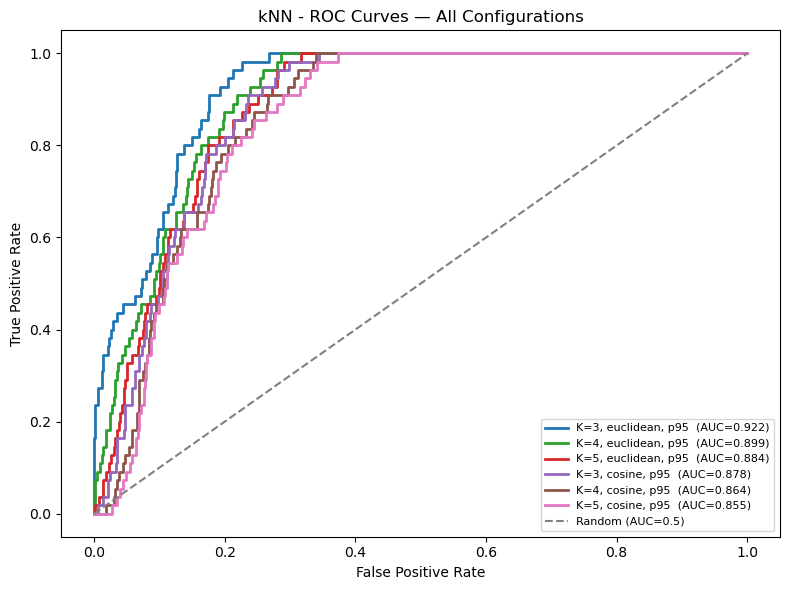

In [68]:
fig, ax = plt.subplots(figsize=(8, 6))

# Use distinct colors for euclidean vs cosine
colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, r in enumerate(results):
    ax.plot(r['fpr'], r['tpr'], lw=2, color=colors[i],
            label=f"{r['label']}  (AUC={r['roc_auc']:.3f})")

# Random baseline
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC=0.5)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('kNN - ROC Curves — All Configurations')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('../figures/knn_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

All 6 curves sit well above the random baseline (AUC=0.5), confirming the model has genuine discriminative ability across all configurations. Rankings by AUC:

| Rank | Configuration | AUC |
|------|--------------|-----|
| 1 | K=3, euclidean | 0.922 |
| 2 | K=4, euclidean | 0.899 |
| 3 | K=5, euclidean | 0.884 |
| 4 | K=3, cosine | 0.878 |
| 5 | K=4, cosine | 0.864 |
| 6 | K=5, cosine | 0.855 |

**Euclidean vs cosine:** Euclidean outperforms cosine at every K value. K=3 euclidean (blue) hugs the top-left corner the tightest, confirming it has the best threshold-independent separation ability.

**Effect of K:** Smaller K consistently produces higher AUC for both metrics. As K increases from 3→4→5, AUC drops by roughly 0.02 per step for both euclidean and cosine.

**Key Takeaway:** K=3 euclidean achieves the highest AUC of 0.922, a notable improvement over the previous best of 0.884 (K=5, euclidean). This confirms that reducing K improves the model's ability to rank anomalies above normal samples.

## 8. Summary Table

A single table summarising all key metrics across every configuration. Sorted by ROC-AUC (descending) so the best-performing setup appears first.

- **AUC** — threshold-independent ranking ability (higher is better)
- **TP** — anomalies correctly caught (higher is better)
- **FN** — anomalies missed (lower is better)
- **FP** — normal samples falsely flagged (lower is better)
- **Recall** — TP / (TP + FN), the fraction of anomalies detected
- **Precision** — TP / (TP + FP), the fraction of flagged samples that are real anomalies

In [69]:
# Build summary DataFrame
summary = pd.DataFrame([{
    'Configuration':  r['label'],
    'K':              r['k'],
    'Metric':         r['metric'],
    'Threshold':      round(r['threshold'], 3),
    'AUC':            round(r['roc_auc'], 3),
    'TP':             int(r['tp']),
    'FN':             int(r['fn']),
    'FP':             int(r['fp']),
    'TN':             int(r['tn']),
    'Recall':         round(r['recall'], 3),
    'Precision':      round(r['precision'], 3),
} for r in results])

# Sort by AUC descending
summary = summary.sort_values('AUC', ascending=False).reset_index(drop=True)

display(summary)

,Configuration,K,Metric,Threshold,AUC,TP,FN,FP,TN,Recall,Precision
0,"K=3, euclidean, p95",3,euclidean,15.879,0.922,25,30,61,1154,0.455,0.291
1,"K=4, euclidean, p95",4,euclidean,18.002,0.899,20,35,61,1154,0.364,0.247
2,"K=5, euclidean, p95",5,euclidean,19.285,0.884,16,39,61,1154,0.291,0.208
3,"K=3, cosine, p95",3,cosine,0.354,0.878,13,42,61,1154,0.236,0.176
4,"K=4, cosine, p95",4,cosine,0.404,0.864,7,48,61,1154,0.127,0.103
5,"K=5, cosine, p95",5,cosine,0.435,0.855,5,50,61,1154,0.091,0.076


## 9. Final Summary

**K=3, euclidean, p95 is the best model.** Here's the full breakdown:

---

**Summary Table**

K=3 euclidean wins on every metric:
- **Highest AUC: 0.922** — best threshold-independent ranking ability
- **Highest TP: 25** — caught the most anomalies out of all 6 configurations
- **Lowest FN: 30** — missed the fewest anomalies
- **Highest Recall: 0.455** — detected 45% of ambient samples, nearly double the previous best (K=5 euclidean at 29%)

---

**Confusion Matrices**

Euclidean clearly outperforms cosine at every K value:
- K=3 euclidean: **TP=25, FN=30** — best overall
- K=4 euclidean: **TP=20, FN=35** — second best
- K=5 euclidean: **TP=16, FN=39**
- K=3 cosine: **TP=13, FN=42** — best cosine config but still significantly behind euclidean
- K=4 cosine: **TP=7, FN=48**
- K=5 cosine: **TP=5, FN=50** — worst of all configurations

All configurations share **FP=61 and TN=1154**, meaning the threshold behaviour on normal samples is identical across all runs.

---

**ROC Curves**

K=3 euclidean (blue, AUC=0.922) sits closest to the top-left corner. All euclidean curves rank above all cosine curves. AUC drops consistently as K increases for both metrics (~0.02 per step).

---

**Compared to the Previous Best (K=5, K=25, K=100 experiment):**

| Metric | Previous best (K=5, euclidean) | New best (K=3, euclidean) | Improvement |
|--------|-------------------------------|--------------------------|-------------|
| AUC | 0.884 | 0.922 | +0.038 |
| TP | 16 | 25 | +9 |
| FN | 39 | 30 | -9 |
| Recall | 0.291 | 0.455 | +0.164 |

---

**Key Insight — Why Smaller K Wins:**

Smaller K makes the model more sensitive to local differences. With K=3, an ambient sample only needs to be far from its 3 closest normal neighbors to score high. As K grows, more neighbors are averaged, smoothing out local differences and making it harder to flag anomalies. The consistent trend across both metrics (euclidean and cosine) confirms this — reducing K from 5→3 is the single most impactful change tested so far.